In [1]:
from lab1.src.fetch.arxiv_fetcher import ArxivFetcher
from lab1.src.graph.cluster_graph import ClusterGraph
from lab1.src.graph.links_graph import LinksGraph
from lab1.src.graph.publications_graph import PublicationsGraph
from lab1.src.keyword.keyword_scoring_processor import KeywordScoringProcessor
from lab1.src.pages.pages_processor import PagesProcessor
from lab1.src.save.json_saver import save_to_json
from lab1.src.fetch.json_fetcher import fetch_from_json
from lab1.src.constant.arxiv import CATEGORY

## №1 Выбрать тематику научных публикаций, любую область знаний, например, machine learning или artificial intelligence.

In [2]:
print(f"категория {CATEGORY}")

250 50 eess.IV


## №2 Скачать с https://arxiv.org/ данные о научных публикациях по выбранной тематике. Выгрузить названия, авторов и аннотации статей. Скачивать через api https://info.arxiv.org/help/api/user-manual.html. Не менее 250 публикаций.

In [3]:
need_to_download_pages = False
fetcher = ArxivFetcher()

pages = None
if need_to_download_pages:
    pages = fetcher.fetch_arxiv_pages_or_get_cashed()
    save_to_json(pages)
else:
    pages = fetch_from_json()

In [4]:
page_processor = PagesProcessor(pages)

## №3 Выделить ключевые слова по каждой публикации (используйте названия и аннотации).

In [5]:
page_processor.show_pages_with_keywords_count()

Найдено 45 статьи/ей с ключевыми словами


In [6]:
page_processor.get_samples()

,title,authors,summary,keywords
103,Fringe pattern analysis using deep learning,"[Shijie Feng, Qian Chen, Guohua Gu, Tianyang T...","In many optical metrology techniques, fringe p...",None
69,Joint Bilateral Filter for Signal Recovery fro...,"[Supratim Gupta, Susant Kumar Panigrahi]","Thresholding of Curvelet Coefficients, for ima...",None
238,Bridge Deck Delamination Segmentation Based on...,"[Chongsheng Cheng, Zhexiong Shang, Zhigang Shen]",Environmental and surface texture-induced temp...,"[Thermography, Delamination segmentation, Brid..."
98,Combining Radon transform and Electrical Capac...,"[Yves Capdeboscq, Hrand Mamigonians, Aslam Sul...",This paper describes a coplanar non invasive n...,None
13,Efficient and fast algorithms to generate holo...,"[Naomi Holland, Dustin Stuart, Oliver Barter, ...",We discuss and compare three algorithms for ge...,None
95,A Convex Model for Edge-Histogram Specificatio...,"[Kelvin C. K. Chan, Raymond H. Chan, Mila Niko...",The goal of edge-histogram specification is to...,None
59,Introducing A Public Stereoscopic 3D High Dyna...,[Amin Banitalebi-Dehkordi],High Dynamic Range (HDR) displays and cameras ...,None
21,Mosaicked multispectral image compression base...,"[Kazuma Shinoda, Madoka Hasegawa, Masahiro Yam...",Multispectral imaging has been utilized in man...,None
156,Lung Cancer Tumor Region Segmentation Using Re...,"[Uday Kamal, Abdul Muntakim Rafi, Rakibul Hoqu...",The performance of a computer-aided automated ...,[Lung Tumor · CT scan · Segmentation · U-Net ·...
146,Optimized Fourier Bilateral Filtering,"[Sanjay Ghosh, Pravin Nair, Kunal N. Chaudhury]",We consider the problem of approximating a tru...,None


In [8]:
page_processor.update_keywords()

In [22]:
page_processor.get_samples()

,title,authors,summary,keywords
149,Self-Refining Deep Symmetry Enhanced Network f...,"[Hong Liu, Hanrong Ye, Xia Li, Wei Shi, Mengyu...",Rain removal aims to remove the rain streaks o...,"[rain removal rain removal, removal rain, rain..."
226,Perceptual Quality Study on Deep Learning base...,"[Zhengxue Cheng, Pinar Akyazi, Heming Sun, Jir...",Recently deep learning based image compression...,"[promising results based, deep learning, deep ..."
170,An effective clustering method based on data i...,"[Elyas Rashno, Behrouz Minaei-Bidgolia, Yanhui...","In this work, a new clustering algorithm is pr...","[neutrosophic set, clustering, proposed cost, ..."
154,A Generalized Structured Low-Rank Matrix Compl...,"[Yue Hu, Xiaohan Liu, Mathews Jacob]",Recent theory of mapping an image into a struc...,"[image recovery recent theory, structured low-..."
219,UAV Detection: A STDP trained Deep Convolution...,[Paul Kirkland],The Dynamic Vision Sensor (DVS) has many attri...,"[dynamic vision sensor, spiking neural network..."
34,Estimating Depth-Salient Edges And its Applica...,"[Sameeulla Khan Md, Sumohana Channappayya]",The human visual system pays attention to sali...,"[estimating depth-salient edges, system pays, ..."
100,Joint optimization of multispectral filter arr...,"[Kazuma Shinoda, Maru Kawase, Madoka Hasegawa,...",A capturing system with multispectral filter a...,"[shortening the capture, system with multispec..."
10,Diffraction Influence on the Field of View and...,"[Zhila Esna Ashari, Zahra Kavehvash, Khashayar...",The influence of the diffraction limit on the ...,"[ini, ini system along arbitrarily, estimated ..."
66,Collaborative Sparse Priors for Infrared Image...,"[Xuelu Li, Vishal Monga]",Feature extraction from infrared (IR) images r...,"[images remains a challenging, feature extract..."
245,Learning Image and Video Compression through S...,"[Zhengxue Cheng, Heming Sun, Masaru Takeuchi, ...",Compression has been an important research top...,"[important research, learning image, video com..."


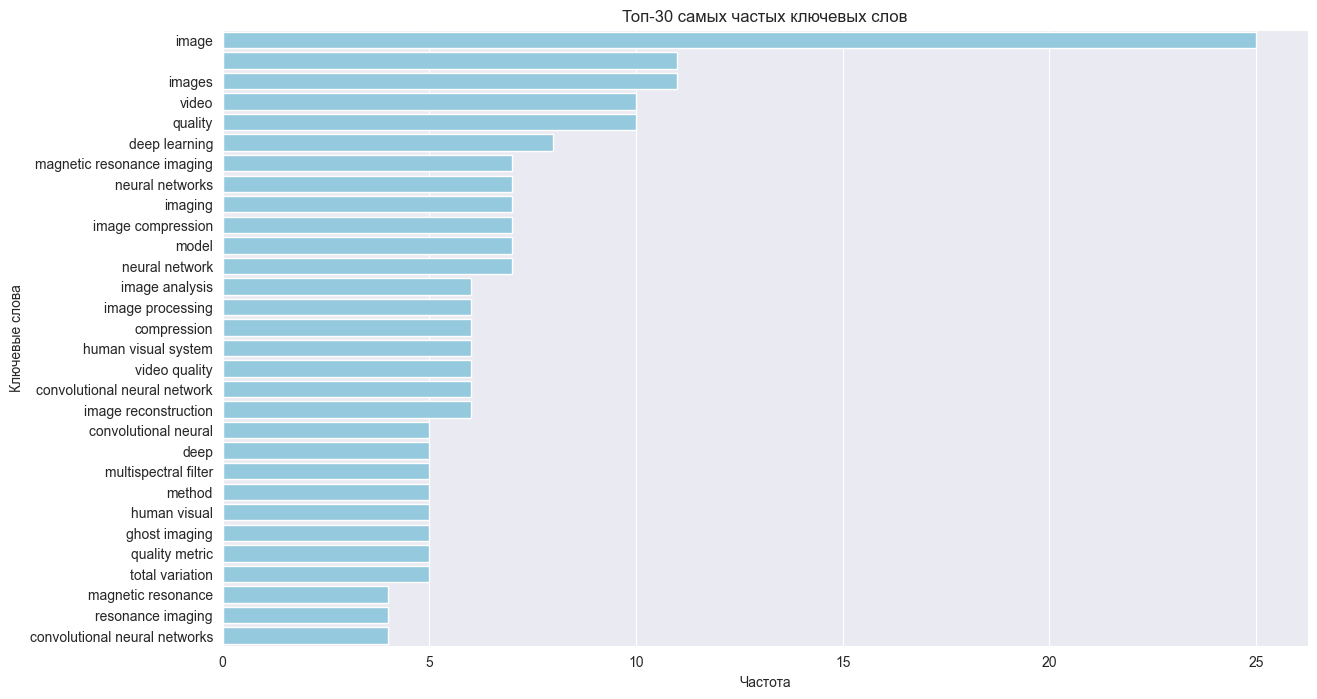

In [10]:
page_processor.show_most_common_keywords()

## №4 Построить связи между ключевыми словами на основе их принадлежности публикациям с использованием библиотеки https://networkx.org/ (как альтернативный вариант можно посмотреть https://graph-tool.skewed.de/static/doc/index.html, https://cosmograph.app/docs/cosmograph/Cosmograph%20Python/configuration/)

In [11]:
links_graph = LinksGraph(page_processor)

In [12]:
links_graph.show()

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

## №5. Определить кластеры ключевых слов на графе. Оценить качество кластеризации (например, по модулярности). Интерпретировать результат.

In [13]:
cluster_graph = ClusterGraph(links_graph.edges, links_graph.vertices)

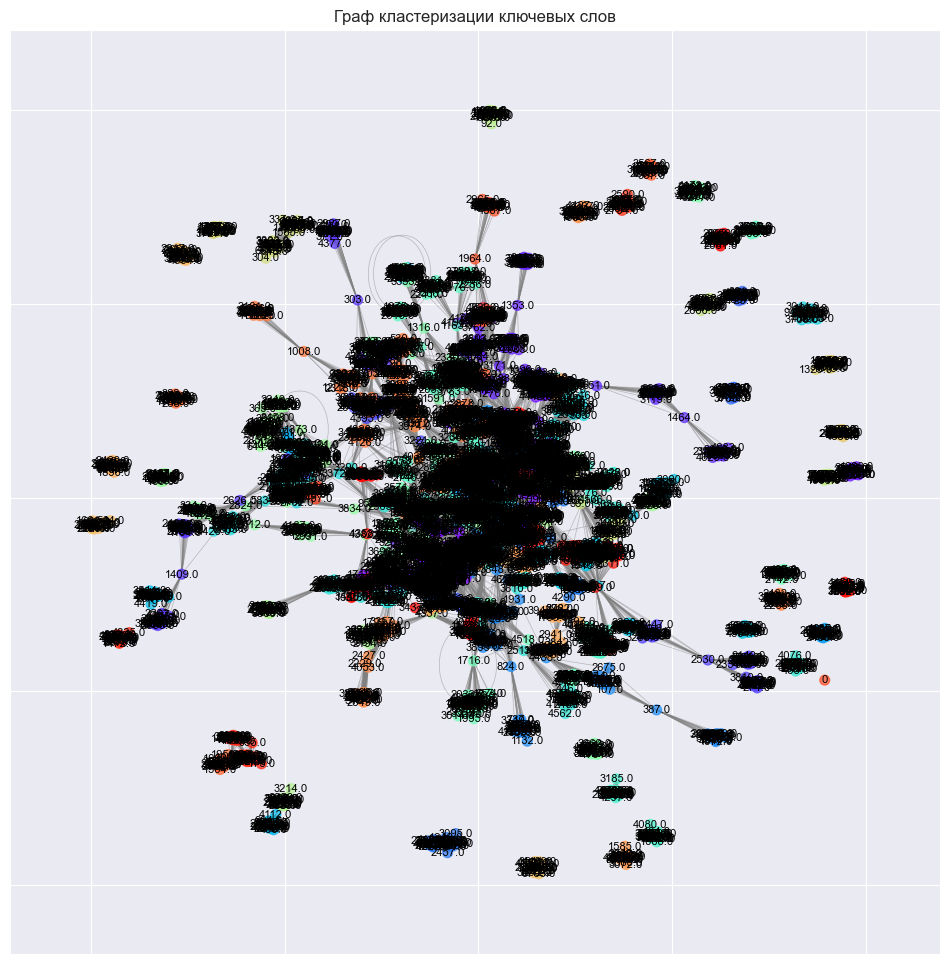

In [15]:
cluster_graph.show()

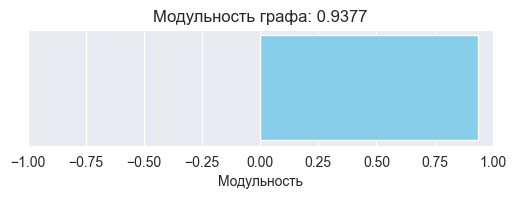

Информация о кластерах
Кластер: 0
Некоторые ключевые слова: Assessing Visual Quality of Omnidirectional Videos...
Кластер: 1
Некоторые ключевые слова: Assessing Visual Quality of Omnidirectional Videos...
Кластер: 2
Некоторые ключевые слова: Image Acquisition System Using On Sensor Compressed Sampling Technique...
Кластер: 3
Некоторые ключевые слова: Neuromorphic adaptive edge-preserving denoising filter...
Кластер: 4
Некоторые ключевые слова: Statistically Segregated k-Space Sampling for Accelerating
  Multiple-Acquisition MRI...
Кластер: 5
Некоторые ключевые слова: Statistically Segregated k-Space Sampling for Accelerating
  Multiple-Acquisition MRI...
Кластер: 6
Некоторые ключевые слова: Light Field Retargeting for Multi-Panel Displays...
Кластер: 8
Некоторые ключевые слова: A Semi-Automated Technique for Internal Jugular Vein Segmentation in
  Ultrasound Images Using Active Contours...
Кластер: 16
Некоторые ключевые слова: Silver Standard Masks for Data Augmentation Applied to
  De

In [16]:
cluster_graph.show_info()

## №6. Найти ключевые слова с наибольшими значениями центральности в выбранной тематике (например, degree centrality, betweenness centrality, eigenvector centrality, closeness centrality). Интерпретировать результаты.

In [17]:
keyword_scoring_processor = KeywordScoringProcessor(cluster_graph)

In [18]:
keyword_scoring_processor.show_scoring_results()

Топ 5 наборов ключевых слов по degree centrality:
Image Acquisition System Using On Sensor Compressed Sampling Technique: 0.0948
Learning Based Segmentation of CT Brain Images: Application to
  Post-Operative Hydrocephalic Scans: 0.0436
Assessing Visual Quality of Omnidirectional Videos: 0.0408
Exploiting Occlusion in Non-Line-of-Sight Active Imaging: 0.0343
Predicting Encoded Picture Quality in Two Steps is a Better Way: 0.0343




Топ 5 наборов ключевых слов по closeness centrality:
Image Acquisition System Using On Sensor Compressed Sampling Technique: 0.2946
Optimal Physical Preprocessing for Example-Based Super-Resolution: 0.2557
Learning Based Segmentation of CT Brain Images: Application to
  Post-Operative Hydrocephalic Scans: 0.2467
Polyp Segmentation in Colonoscopy Images Using Fully Convolutional
  Network: 0.2465
Mosaicked multispectral image compression based on inter- and intra-band
  correlation: 0.2453




Топ 5 наборов ключевых слов по eigenvector centrality:
Image Acqu

## №7. Построить граф публикаций: если ключевое слово является тегом для двух публикаций, значит, между ними связь есть. Чем больше общих ключевых слов, тем сильнее связь (выше вес ребра). Реализовать поиск наиболее близких к заданной пользователем публикаций на графе.

In [19]:
publications_graph = PublicationsGraph(page_processor)

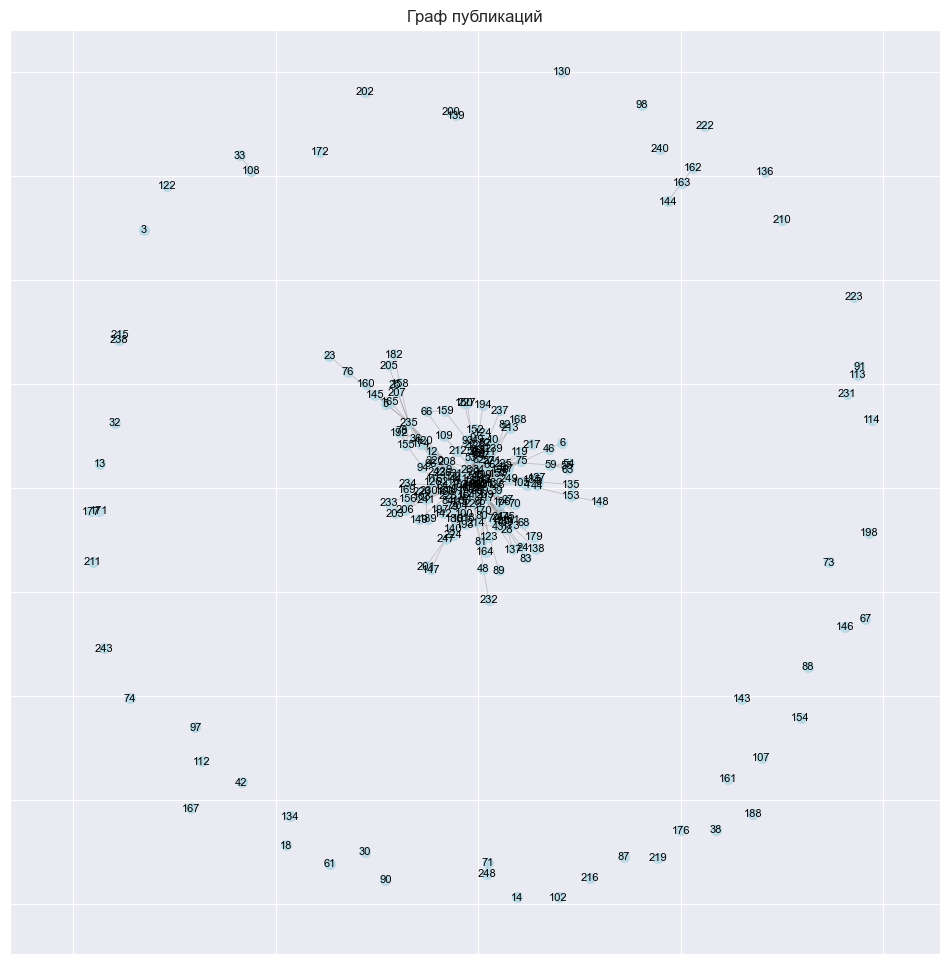

In [20]:
publications_graph.show()

In [21]:
result = publications_graph.find_neighbors(212)

print(f"Для публикации {result['publication']} с заголовком \"{result['publication_title']}\" найдены соседние публикации:")

for n, title in result["titles"]:
    print(f"  - {n}: \"{title}\"")


Для публикации 212 с заголовком "Total Variation and Tight Frame Image Segmentation with Intensity
  Inhomogeneity" найдены соседние публикации:
  - 9: Silver Standard Masks for Data Augmentation Applied to
  Deep-Learning-Based Skull-Stripping
  - 93: Comparative survey: People detection, tracking and multi-sensor Fusion
  in a video sequence
  - 116: A Brief Survey and an Application of Semantic Image Segmentation for
  Autonomous Driving
  - 152: Validation of Biometric Identification of Dairy Cows based on Udder NIR
  Images
  - 221: Hyperspectral Unmixing via Deep Autoencoder Networks for a Generalized
  Linear-Mixture/Nonlinear-Fluctuation Model
